# 07 — Hybrid Multi-Agent System · the merge point for all agents

This is the **single notebook where every agent is merged into one system.** The earlier notebooks
each *produce one agent* and save its signal to `artifacts/notebooks_v2/<agent>/`:

| # | Notebook | Agent | Kind |
|---|----------|-------|------|
| 01 | `01_lgbm`     | `lgbm`     | gradient boosting (tabular) |
| 02 | `02_mamba`    | `mamba`    | selective state-space |
| 03 | `03_tcn`      | `tcn`      | dilated causal conv. (TBM, 2-channel) |
| 04 | `05_patchtst` | `patch`    | patch transformer (TBM, 2-channel) |
| 05 | `08_trend`    | `trend`    | rule: trend-following |
| 05 | `08_meanrev`  | `meanrev`  | rule: mean-reversion |
| 05 | `08_volbreak` | `volbreak` | rule: volatility breakout |
| 06 | `09_crossasset` | `crossasset` | learned: cross-asset / sentiment / flow |

Here those eight independent signals are wrapped as **autonomous risk-managed `TradingAgent`s** and
fused by a **`Coordinator`** that allocates capital across them by `online skill × regime
competence`. This is the fund-of-agents layer — not an averaging ensemble (that was the now-archived averaging meta-learner).

**Self-contained:** this notebook inlines the full engine and all evaluation code — run it
top-to-bottom with no local imports. It reads each agent's saved artifacts, so run notebooks
01–04 (learned), 05 (rule) and 06 (cross-asset) first to produce them.

**Leak discipline (carried through every cell):** a weight decided with information up to bar *t*
earns each agent's return over *t → t+1*; every trailing statistic is shifted by ≥1 bar + embargo;
per-regime competence priors see pre-OOS data only.

---
## Part A — coordinator engine (inlined from `mas07.py`)

In [45]:
# Dependencies for the inlined engine
import json
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd

### Configuration

In [46]:
# Learned agents (nonlinear models on the shared feature panel) + rule agents (notebook 08,
# parameter-free classical strategies). The rule agents are structurally orthogonal — their edge
# is strategy logic, not the feature panel — which is what gives the coordinator something to
# rotate into when the learned agents fail together.
LEARNED_AGENTS = ["lgbm", "mamba", "tcn", "patch"]
RULE_AGENTS = ["trend", "meanrev", "volbreak"]
CROSS_AGENTS = ["crossasset"]   # learned, but on orthogonal cross-asset/sentiment/flow info
AGENTS = LEARNED_AGENTS + RULE_AGENTS + CROSS_AGENTS
AGENT_DIR = {"lgbm": "01_lgbm", "mamba": "02_mamba", "tcn": "03_tcn", "patch": "05_patchtst",
             "trend": "08_trend", "meanrev": "08_meanrev", "volbreak": "08_volbreak",
             "crossasset": "09_crossasset"}
# Multiclass TBM agents emit two *independent* softmax channels (P-up, P-down) and decide
# long on P-up and short on P-down. A single saved probability is the P-up channel only, so
# these agents must be backtested with their P-down channel too — otherwise the binary engine
# manufactures shorts whenever P-up is merely low, destroying their genuine (short-heavy) edge.
MULTICLASS = {"tcn", "patch"}
PARADIGM = {
    "lgbm": "gradient boosting (tabular)",
    "mamba": "selective state-space",
    "tcn": "dilated causal conv.",
    "patch": "patch transformer",
    "trend": "rule: trend-following",
    "meanrev": "rule: mean-reversion",
    "volbreak": "rule: volatility breakout",
    "crossasset": "learned: cross-asset / sentiment / flow",
}

OOS_START = pd.Timestamp("2024-05-31")
OOS_END = pd.Timestamp("2026-05-16")
COMPETENCE_START = pd.Timestamp("2023-01-01")  # pre-OOS window common to all four agents

REGIMES = ("chop", "bull", "bear")
REGIME_DATES = {  # reporting-only OOS sub-periods; the live detector is feature-based
    "chop": (pd.Timestamp("2024-05-31"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31")),
}

# Fee model — identical to the base agents' backtests.
MAKER_FEE = 0.0
TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
REALLOC_FEE = 0.0002       # capital reallocation cost across agents (per unit |Δweight|)

EMBARGO_H = 48   # embargo applied to every trailing/online statistic
ANN = np.sqrt(24 * 365)

# --- Coordinator defaults (a-priori reasonable; NOT tuned on the OOS window) -------------
# A 60-day trailing window to score each agent's recent skill, a neutral softmax temperature,
# and a 7-day regime-smoothing window to suppress the whipsaw that wrecks instantaneous routing.
# Proper selection of these belongs on pre-OOS data (purged CV) and is left as future work.
PERF_WIN = 1440        # 60-day trailing window for the online performance score
PERF_TEMP = 0.75       # softmax temperature over trailing Sharpe
REGIME_SMOOTH = 168    # 7-day majority-vote smoothing of the regime label
COMP_FLOOR = 0.15      # floor on the competence tilt so a hot agent is never fully vetoed


def repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("repo root not found")

### Metrics

In [47]:
def sharpe(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)


def sortino(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)


def maxdd(eq: np.ndarray) -> float:
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

### ATR-bracket engine — the agents' own risk-managed execution

In [48]:
def bracket_run(prob, close, high, low, atr, *, long_threshold, short_threshold,
                entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                min_sl=0.01, with_fees=True, prob_dn=None, **_ignored):
    """Single-pass ATR-bracket backtester (identical logic to the base agents).

    Returns three full-length arrays: the equity curve ``eq``, the held position ``pos`` in
    ``{-1, 0, +1}``, and a held ``conf`` in ``[0, 1]`` (entry-probability strength carried for
    the life of the trade). Equity is net of the maker/taker fee model and short funding.

    ``prob_dn`` selects the entry convention:

    * ``None`` — binary single-probability agent (LightGBM, Mamba): long when
      ``prob > long_threshold``, short when ``prob < short_threshold``.
    * an array — multiclass TBM agent (TCN, PatchTST): ``prob`` is the P-up channel and
      ``prob_dn`` the P-down channel; long when ``prob > long_threshold``, short when
      ``prob_dn > short_threshold`` (long takes priority, mirroring the base notebooks).
    """
    n = len(close)
    eq = np.ones(n); pos = np.zeros(n); conf = np.zeros(n)
    cur = 1.0
    in_pos = False; direction = None
    entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    held_conf = 0.0; hold = cd = 0; funding = 0.0; pend = None
    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            pos[i] = 1.0 if direction == "long" else -1.0
            conf[i] = held_conf
            ex = False; xpx = 0.0; xf = 0.0
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif hi >= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
                else:
                    if hi >= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif lo <= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
            if ex:
                g = ((xpx - entry_px) / entry_px if direction == "long" else (entry_px - xpx) / entry_px)
                net = g - (entry_fee + xf if with_fees else 0.0) + funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                in_pos = False; cd = cooldown; funding = 0.0
        elif pend is not None:
            d, lim, ps, pt, pc = pend
            if d == "long":
                fill = lo <= lim + BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            else:
                fill = hi >= lim - BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            entry_px = lim if fill else px
            sl_px, tp_px, entry_fee = ps, pt, ef
            direction = d; in_pos = True; pos_eq = cur; hold = 0; funding = 0.0
            held_conf = pc; pos[i] = 1.0 if d == "long" else -1.0; conf[i] = pc
            eq[i] = cur; pend = None
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif not np.isnan(prob[i]) and i + 1 < n:
            a = max(atr[i], min_sl)
            if prob_dn is None:
                go_long, go_short = prob[i] > long_threshold, prob[i] < short_threshold
                pc_long = pc_short = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
            else:
                go_long, go_short = prob[i] > long_threshold, prob_dn[i] > short_threshold
                pc_long = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
                pc_short = float(np.clip(2 * abs(prob_dn[i] - 0.5), 0, 1))
            if go_long:
                pend = ("long", px * (1 - entry_atr_mult * a), px * (1 - sl_atr_mult * a),
                        px * (1 + tp_atr_mult * a), pc_long)
            elif go_short:
                pend = ("short", px * (1 + entry_atr_mult * a), px * (1 + sl_atr_mult * a),
                        px * (1 - tp_atr_mult * a), pc_short)
            eq[i] = cur
        else:
            eq[i] = cur
    return eq, pos, conf

### Regime detector (feature-based, works across all history -> leak-free priors)

In [49]:
class RegimeDetector:
    """Label each bar ``chop`` / ``bull`` / ``bear`` from *stationary* trend/volatility features
    only. Calendar/monotonic features are deliberately excluded (they caused the meta-learner's
    regime memorisation). The same detector is applied pre-OOS and OOS, which is what lets
    per-regime competence be estimated without leakage.
    """

    def __init__(self, chop_hurst: float = 0.5):
        self.chop_hurst = chop_hurst

    def label(self, df: pd.DataFrame) -> pd.Series:
        trend = df["close_vs_sma_200"] if "close_vs_sma_200" in df else df["sma100_vs_sma200"]
        sideways = df.get("sideways_flag", pd.Series(0, index=df.index)).fillna(0).astype(bool)
        hurst = df.get("hurst_24h", pd.Series(0.5, index=df.index)).fillna(0.5)
        is_chop = sideways | (hurst < self.chop_hurst)
        out = np.where(trend.fillna(0) >= 0, "bull", "bear")
        out = np.where(is_chop, "chop", out)
        return pd.Series(out, index=df.index, name="regime")

### Data panel

In [50]:
def _load_signal(a2: Path, sub: str, kind: str, value: str = "probs") -> pd.Series:
    """Load one channel of an agent's signal. ``value`` picks the file suffix
    (``probs`` -> ``{kind}_probs.npy``, ``pdown`` -> ``{kind}_pdown.npy``); both share
    the ``{kind}_index.npy`` timestamps."""
    f = a2 / sub
    p = np.load(f / f"{kind}_{value}.npy")
    idx = pd.to_datetime(np.load(f / f"{kind}_index.npy"), unit="ns")
    return pd.Series(p, index=idx)


def _spliced_signal(a2: Path, sub: str, index: pd.Index, value: str = "probs") -> pd.Series:
    """Walk-forward signal over full history, with the OOS window overwritten by the
    held-out OOS signal (the same splice used for the P-up channel)."""
    wfo = _load_signal(a2, sub, "wfo", value).reindex(index)
    oos = _load_signal(a2, sub, "oos", value).reindex(index)
    mask = (index >= OOS_START) & (index <= OOS_END) & oos.notna()
    wfo.loc[mask] = oos.loc[mask]
    return wfo


def load_panel() -> pd.DataFrame:
    """Aligned panel: each agent's walk-forward probability over full history spliced with its
    OOS probability over the OOS window, plus price, return, regime and stationary features.
    """
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    df = pd.read_parquet(repo / "data" / "features" / "BTCUSDT_1h_unified.parquet")
    df.index = df.index.tz_localize(None) if df.index.tz else df.index

    panel = pd.DataFrame(index=df.index)
    for a in AGENTS:
        panel[a] = _spliced_signal(a2, AGENT_DIR[a], df.index)
        if a in MULTICLASS:  # P-down channel for the dual-channel TBM agents
            panel[f"{a}_dn"] = _spliced_signal(a2, AGENT_DIR[a], df.index, "pdown")

    for c in ["close", "high", "low", "atr_14_pct", "close_vs_sma_200", "sma100_vs_sma200",
              "sideways_flag", "hurst_24h", "bb_width_pct", "vol_ratio_24h", "trend_score"]:
        if c in df:
            panel[c] = df[c]
    panel["ret"] = df["close"].pct_change().fillna(0.0)
    panel["regime"] = RegimeDetector().label(df)
    return panel

### Agents — autonomous, risk-managed traders

In [51]:
@dataclass
class TradingAgent:
    """One base model wrapped as an autonomous, risk-managed trading agent.

    On :meth:`build` it runs its own tuned ATR-bracket strategy over the full history, yielding a
    realised equity curve, a per-bar return stream ``g`` (what the coordinator allocates over),
    a held position path, and a communicated confidence. Each agent keeps its authentic strategy
    — including any directional bias; reconciling those biases across regimes is the
    coordinator's job, not the agent's.
    """

    name: str
    prob: pd.Series
    best_params: dict
    prob_dn: pd.Series = field(default=None, repr=False)  # P-down channel for multiclass agents
    eq: pd.Series = field(default=None, repr=False)
    g: pd.Series = field(default=None, repr=False)
    position: pd.Series = field(default=None, repr=False)
    confidence: pd.Series = field(default=None, repr=False)

    @property
    def paradigm(self) -> str:
        return PARADIGM.get(self.name, "unknown")

    def build(self, panel: pd.DataFrame) -> "TradingAgent":
        prob_dn = self.prob_dn.reindex(panel.index).values if self.prob_dn is not None else None
        eq, pos, conf = bracket_run(
            self.prob.reindex(panel.index).values,
            panel["close"].values, panel["high"].values, panel["low"].values,
            panel["atr_14_pct"].values, prob_dn=prob_dn, **self.best_params)
        self.eq = pd.Series(eq, index=panel.index, name=self.name)
        self.g = pd.Series(np.diff(np.log(np.maximum(eq, 1e-12)), prepend=0.0),
                           index=panel.index, name=self.name)
        self.position = pd.Series(pos, index=panel.index, name=self.name)
        self.confidence = pd.Series(conf, index=panel.index, name=self.name)
        return self


def build_agents(panel: pd.DataFrame, a2: Path) -> dict[str, TradingAgent]:
    agents: dict[str, TradingAgent] = {}
    for a in AGENTS:
        bp = json.load(open(a2 / AGENT_DIR[a] / "results.json")).get("best_params", {})
        pdn = panel[f"{a}_dn"] if f"{a}_dn" in panel else None
        agents[a] = TradingAgent(a, panel[a], bp, prob_dn=pdn).build(panel)
    return agents

### Competence priors (per-regime, pre-OOS only) and online reliability

In [52]:
def estimate_competence(agents: dict[str, TradingAgent], panel: pd.DataFrame) -> pd.DataFrame:
    """Per-regime competence of each agent, measured on the pre-OOS window only (leak-free).

    Competence = annualised Sharpe of the agent's *active-bar* returns within that regime,
    passed through ReLU (a non-positive track record earns zero trust), then normalised within
    each regime so weights are comparable. This is the gate's prior on *who is good where*.
    """
    pre = (panel.index >= COMPETENCE_START) & (panel.index < OOS_START)
    rows = {}
    for a, ag in agents.items():
        active = ag.position.abs() > 0
        row = {}
        for r in REGIMES:
            m = pre & active & (panel["regime"] == r)
            seg = ag.g[m].values
            if len(seg) > 50 and seg.std() > 0:
                row[r] = max(seg.mean() / (seg.std() + 1e-12) * ANN, 0.0)
            else:
                row[r] = 0.0
        rows[a] = row
    comp = pd.DataFrame(rows).T.reindex(AGENTS)
    comp = comp.div(comp.sum(axis=0).replace(0, np.nan), axis=1).fillna(1.0 / len(AGENTS))
    return comp


def trailing_sharpe(agents: dict[str, TradingAgent], win: int = PERF_WIN,
                    embargo: int = EMBARGO_H) -> pd.DataFrame:
    """Trailing annualised Sharpe of each agent's own returns (leak-free).

    This is the online skill score the coordinator chases — it already reflects the *current*
    market regime (a bear specialist's trailing Sharpe rises in a bear) without needing an
    explicit, whipsaw-prone regime label.
    """
    out = {}
    for a, ag in agents.items():
        mu = ag.g.rolling(win, min_periods=200).mean().shift(1 + embargo)
        sd = ag.g.rolling(win, min_periods=200).std().shift(1 + embargo)
        out[a] = (mu / (sd + 1e-12) * ANN).fillna(0.0)
    return pd.DataFrame(out)


def smoothed_competence(competence: pd.DataFrame, panel: pd.DataFrame,
                        smooth: int = REGIME_SMOOTH) -> pd.DataFrame:
    """Per-bar competence vector under a *smoothed* (majority-vote) regime label, to suppress
    the whipsaw that makes instantaneous regime routing unprofitable."""
    code = panel["regime"].map({"chop": 0, "bull": 1, "bear": 2})
    sm = code.rolling(smooth, min_periods=1).apply(
        lambda x: np.bincount(x.astype(int), minlength=3).argmax(), raw=True)
    inv = {0: "chop", 1: "bull", 2: "bear"}
    smr = sm.map(inv)
    return pd.DataFrame(competence.T.reindex(smr.values).values,
                        index=panel.index, columns=AGENTS)

### Coordinator — regime-gated capital allocation (mixture of experts)

In [53]:
@dataclass
class Coordinator:
    """Mixture-of-experts capital allocator over autonomous agents.

    Two information sources are fused, each addressing a failure we diagnosed empirically:

    * **Online performance gate** — a softmax over every agent's *trailing Sharpe*. This is the
      workhorse: it adaptively backs whoever is currently skilful and needs no regime label, so
      it sidesteps the whipsaw that made instantaneous regime-routing lose money.
    * **Smoothed-regime competence tilt** — the pre-OOS, per-regime competence prior under a
      7-day-smoothed regime label, multiplied in as a structural prior on *who is good where*.

    Per-bar capital weight::

        raw_i = softmax_j( trailingSharpe_j / temp )_i  *  ( competence[i, regime~_t] + floor )
        w_i   = raw_i / sum_i raw_i

    The portfolio return is ``sum_i w_i(t-1) * g_i(t)`` minus a small reallocation cost; an agent
    that is flat contributes zero and its weight acts as cash. No confidence/activity multiplier
    is used — it starved the selective specialists and was found to hurt.
    """

    competence: pd.DataFrame
    temp: float = PERF_TEMP
    smooth: int = REGIME_SMOOTH
    floor: float = COMP_FLOOR

    def allocate(self, agents: dict[str, TradingAgent], panel: pd.DataFrame,
                 perf: pd.DataFrame) -> pd.DataFrame:
        idx = panel.index
        z = (perf[AGENTS] / self.temp).clip(-10, 10)
        soft = np.exp(z); soft = soft.div(soft.sum(axis=1), axis=0).fillna(1.0 / len(AGENTS))
        tilt = smoothed_competence(self.competence, panel, self.smooth) + self.floor
        raw = soft.values * tilt.values
        W = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-12)
        return pd.DataFrame(W, index=idx, columns=AGENTS)

### Evaluation

In [54]:
def _oos(panel: pd.DataFrame) -> pd.DatetimeIndex:
    return panel.index[(panel.index >= OOS_START) & (panel.index <= OOS_END)]


def portfolio_equity(weights: pd.DataFrame, agents: dict[str, TradingAgent],
                     idx: pd.DatetimeIndex) -> np.ndarray:
    """Equity of a capital-allocation portfolio over agents (leak-free: w[t-1] earns g[t])."""
    W = weights.reindex(idx).fillna(0.0)[AGENTS].values
    G = pd.DataFrame({a: agents[a].g for a in AGENTS}).reindex(idx).fillna(0.0)[AGENTS].values
    n = len(idx)
    eq = np.ones(n); cur = 1.0; prev = np.zeros(len(AGENTS))
    for t in range(n):
        r = float((prev * G[t]).sum()) if t > 0 else 0.0
        realloc = float(np.abs(W[t] - prev).sum()) * REALLOC_FEE
        cur *= (1.0 + r - realloc); eq[t] = cur
        prev = W[t]
    return eq


def evaluate_equity(eq_full: pd.Series, idx: pd.DatetimeIndex, name: str) -> tuple[dict, np.ndarray]:
    seg = eq_full.reindex(idx).values
    seg = seg / seg[0]
    bh_first = idx[0]
    row = dict(name=name, ret=float(seg[-1] - 1), sharpe=sharpe(seg), sortino=sortino(seg),
               maxdd=maxdd(seg))
    return row, seg


def regime_breakdown(eq_full: pd.Series, panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for r in REGIMES:
        s, e = REGIME_DATES[r]
        m = (eq_full.index >= s) & (eq_full.index <= e)
        if m.sum() < 24:
            continue
        seg = eq_full[m].values; seg = seg / seg[0]
        out.append({"regime": r, "ret": f"{seg[-1] - 1:+.1%}", "sharpe": f"{sharpe(seg):.2f}",
                    "maxdd": f"{maxdd(seg):.1%}"})
    return pd.DataFrame(out)

### Orchestration

In [55]:
def run_pipeline(save: bool = True, verbose: bool = True) -> dict:
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    arts = a2 / "07_mas"; arts.mkdir(parents=True, exist_ok=True)

    panel = load_panel()
    agents = build_agents(panel, a2)
    competence = estimate_competence(agents, panel)
    perf = trailing_sharpe(agents)
    coordinator = Coordinator(competence)
    weights = coordinator.allocate(agents, panel, perf)

    idx = _oos(panel)
    bh = pd.Series((1.0 + panel["ret"].reindex(idx)).cumprod().values, index=idx)

    results = []; equities = {}

    def _add_equity(name, eq_full):
        row, seg = evaluate_equity(eq_full, idx, name)
        row["alpha"] = float(seg[-1] - bh.values[-1] / bh.values[0])
        results.append(row); equities[name] = seg
        return row

    # standalone agents (their authentic risk-managed strategy)
    for a, ag in agents.items():
        _add_equity(f"{a}", ag.eq)
    # naive equal-weight fund-of-agents (1/N each → gross exposure 1.0, matching the coordinator)
    ew_w = pd.DataFrame(1.0 / len(AGENTS), index=panel.index, columns=AGENTS)
    ew_eq = pd.Series(portfolio_equity(ew_w, agents, idx), index=idx)
    _add_equity("Naive EW fund", ew_eq.reindex(panel.index).ffill().fillna(1.0))
    # coordinator
    coord_eq_oos = pd.Series(portfolio_equity(weights, agents, idx), index=idx)
    coord_eq_full = coord_eq_oos.reindex(panel.index).ffill().fillna(1.0)
    coord_row = _add_equity("Coordinator (MAS)", coord_eq_full)
    _add_equity("BTC Buy & Hold", pd.Series(
        (1.0 + panel["ret"]).cumprod().values, index=panel.index))

    lb = pd.DataFrame(results).sort_values("sharpe", ascending=False).reset_index(drop=True)
    breakdown = regime_breakdown(coord_eq_full, panel)
    mean_w = weights.reindex(idx).mean()

    if verbose:
        print("=== Per-regime competence priors (pre-OOS Sharpe, normalised, leak-free) ===")
        print(competence.round(3).to_string())
        print(f"\nMean coordinator capital weights (OOS): {mean_w.round(3).to_dict()}")
        print(f"Coordinator mean gross exposure (OOS): {weights.reindex(idx).sum(axis=1).mean():.2f}\n")
        show = lb.copy()
        for c in ["ret", "maxdd", "alpha"]:
            show[c] = (show[c] * 100).round(1)
        show["sharpe"] = show["sharpe"].round(2); show["sortino"] = show["sortino"].round(2)
        print(show[["name", "ret", "sharpe", "sortino", "maxdd", "alpha"]].to_string(index=False))
        print("\n=== Coordinator regime breakdown ===")
        print(breakdown.to_string(index=False))

    out = dict(
        notebook="07_multi_agent_v1", created=pd.Timestamp.now().isoformat(),
        design="regime-gated mixture-of-experts capital allocation over autonomous "
               "risk-managed agents; competence priors measured pre-OOS, online reliability "
               "adapts within OOS; leak-free (w[t-1] earns g[t]).",
        oos_period=f"{OOS_START.date()} -> {OOS_END.date()}",
        competence=competence.round(4).to_dict(),
        mean_weights_oos=mean_w.round(4).to_dict(),
        coordinator=coord_row, regime_breakdown=breakdown.to_dict("records"),
        leaderboard=lb.to_dict("records"))
    if save:
        json.dump(out, open(arts / "results.json", "w"), indent=2, default=float)
        lb.to_csv(arts / "leaderboard.csv", index=False)
        competence.to_csv(arts / "competence.csv")
        weights.reindex(idx).to_csv(arts / "weights_oos.csv")
        np.save(arts / "oos_index.npy", idx.values.astype("int64"))
        np.save(arts / "coord_equity.npy", coord_eq_oos.values.astype(np.float32))
        if verbose:
            print(f"\nArtifacts -> {arts}")

    out.update(_equities=equities, _panel=panel, _weights=weights, _agents=agents,
               _coord_eq=coord_eq_full, _bh=bh, _idx=idx)
    return out


def plot_results(out: dict, save: bool = True):
    """Equity curves (coordinator vs agents vs baselines) and the coordinator's capital
    allocation over time. Expects the dict returned by :func:`run_pipeline`."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    arts = repo_root() / "artifacts" / "notebooks_v2" / "07_mas"
    idx = out["_idx"]
    eqs = out["_equities"]
    weights = out["_weights"].reindex(idx).fillna(0.0)
    colours = {"lgbm": "#F7931A", "mamba": "#7B1FA2", "tcn": "#00ACC1", "patch": "#EF5350",
               "trend": "#43A047", "meanrev": "#FB8C00", "volbreak": "#5E35B1",
               "crossasset": "#00695C"}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), height_ratios=[2, 1], sharex=True)
    for name, eq in eqs.items():
        if name == "Coordinator (MAS)":
            ax1.plot(idx, (eq - 1) * 100, lw=2.6, color="k", label=f"{name} ({eq[-1]-1:+.0%})", zorder=5)
        elif name == "BTC Buy & Hold":
            ax1.plot(idx, (eq - 1) * 100, lw=1.2, ls=":", color="#9E9E9E", label=f"{name} ({eq[-1]-1:+.0%})")
        elif name == "Naive EW fund":
            ax1.plot(idx, (eq - 1) * 100, lw=1.4, ls="--", color="#455A64", label=f"{name} ({eq[-1]-1:+.0%})")
        else:
            ax1.plot(idx, (eq - 1) * 100, lw=1.1, alpha=0.8, color=colours.get(name),
                     label=f"{name} ({eq[-1]-1:+.0%})")
    for r, c in [("chop", "#9E9E9E"), ("bull", "#26A69A"), ("bear", "#EF5350")]:
        s, e = REGIME_DATES[r]
        ax1.axvspan(s, min(e, idx[-1]), alpha=0.06, color=c)
    ax1.axhline(0, color="#9E9E9E", lw=0.6, ls=":")
    ax1.set_ylabel("Return (%)"); ax1.legend(fontsize=8, ncol=2)
    ax1.set_title("Multi-agent coordinator vs autonomous agents and baselines (OOS)", fontweight="bold")

    ax2.stackplot(idx, *[weights[a].values for a in AGENTS],
                  labels=AGENTS, colors=[colours[a] for a in AGENTS], alpha=0.85)
    ax2.set_ylabel("Capital weight"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8, ncol=4, loc="upper left")
    ax2.set_title("Coordinator capital allocation over time", fontweight="bold")
    ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    if save:
        fig.savefig(arts / "01_coordinator_equity.png", dpi=160, bbox_inches="tight")
    return fig

---
## Part B — merge the agents and run the coordinator

`AGENTS` (defined in *Configuration* above) is `LEARNED_AGENTS + RULE_AGENTS + CROSS_AGENTS` = the
full eight-agent roster. The cell below verifies every agent's artifacts exist on disk, then runs
the whole pipeline.

In [56]:
# Verify all agents' artifacts exist (produced by notebooks 01–04, 05, 06).
missing = [d for a, d in AGENT_DIR.items()
           if not (repo_root() / "artifacts" / "notebooks_v2" / d / "oos_probs.npy").exists()]
assert not missing, ("missing artifacts — run the producing notebooks first: "
                     + ", ".join(missing) + " (05 → rule agents, 06 → cross-asset, 01–04 → learned)")
print("All", len(AGENT_DIR), "agents present:", list(AGENT_DIR))

All 8 agents present: ['lgbm', 'mamba', 'tcn', 'patch', 'trend', 'meanrev', 'volbreak', 'crossasset']


In [57]:
out = run_pipeline(save=True, verbose=True)

=== Per-regime competence priors (pre-OOS Sharpe, normalised, leak-free) ===
             chop   bull   bear
lgbm        0.264  0.362  0.000
mamba       0.091  0.079  0.160
tcn         0.268  0.251  0.049
patch       0.126  0.000  0.603
trend       0.063  0.144  0.000
meanrev     0.023  0.049  0.019
volbreak    0.041  0.004  0.000
crossasset  0.124  0.112  0.169

Mean coordinator capital weights (OOS): {'lgbm': 0.133, 'mamba': 0.084, 'tcn': 0.191, 'patch': 0.138, 'trend': 0.1, 'meanrev': 0.116, 'volbreak': 0.171, 'crossasset': 0.068}
Coordinator mean gross exposure (OOS): 1.00

             name   ret  sharpe  sortino  maxdd  alpha
    Naive EW fund  48.8    1.96     2.37   -8.0   33.3
         volbreak 127.6    1.20     1.25  -28.1  112.0
              tcn  73.8    1.14     0.92  -13.6   58.3
            patch  36.1    0.87     0.45  -10.7   20.5
            trend  85.0    0.78     0.85  -29.7   69.4
             lgbm  37.8    0.75     0.36  -15.7   22.2
       crossasset  53.4    0.6

### Per-regime competence priors (pre-OOS, leak-free)

Measured on 2023-01 → 2024-05-31 only — each agent's specialisation *before* it sees the test
window — and validated against realised OOS per-regime Sharpe below.

In [58]:
import pandas as pd, numpy as np
competence = pd.DataFrame(out["competence"]); display(competence.round(3))

panel, agents, idx = out["_panel"], out["_agents"], out["_idx"]
oosp = panel.loc[idx]; val = {}
for a, ag in agents.items():
    g = ag.g.reindex(idx).values
    row = {}
    for reg in REGIMES:
        m = (oosp["regime"] == reg).values
        row[reg] = round(g[m].mean() / (g[m].std() + 1e-12) * ANN, 2) if m.sum() > 1 and g[m].std() > 0 else 0.0
    val[a] = row
print("Realised OOS per-regime Sharpe (validation of the priors):")
display(pd.DataFrame(val).T.round(2))

,chop,bull,bear
lgbm,0.264,0.362,0.000
mamba,0.091,0.079,0.160
tcn,0.268,0.251,0.050
patch,0.126,0.000,0.603
trend,0.063,0.144,0.000
meanrev,0.023,0.048,0.019
volbreak,0.041,0.004,0.000
crossasset,0.124,0.112,0.169


Realised OOS per-regime Sharpe (validation of the priors):


,chop,bull,bear
lgbm,1.65,1.83,-1.51
mamba,-0.09,-1.28,1.82
tcn,1.11,-3.63,5.82
patch,1.96,-3.93,3.06
trend,1.97,0.66,-0.69
meanrev,0.75,-0.56,0.24
volbreak,0.48,1.77,1.60
crossasset,-0.26,0.73,1.65


### Leaderboard — coordinator vs every agent vs baselines

All rows on the identical OOS window. The honest benchmark is the **Naive EW fund** (equal weight
across all agents): if the coordinator cannot beat a blind equal split of the same roster, the
allocation logic — not the agents — is the bottleneck.

In [59]:
lb = pd.DataFrame(out["leaderboard"]).copy()
for c in ["ret", "maxdd", "alpha"]:
    lb[c] = (lb[c] * 100).round(1)
lb["sharpe"] = lb["sharpe"].round(2); lb["sortino"] = lb["sortino"].round(2)
display(lb[["name", "ret", "sharpe", "sortino", "maxdd", "alpha"]])

,name,ret,sharpe,sortino,maxdd,alpha
0,Naive EW fund,48.8,1.96,2.37,-8.0,33.3
1,volbreak,127.6,1.20,1.25,-28.1,112.0
2,tcn,73.8,1.14,0.92,-13.6,58.3
3,patch,36.1,0.87,0.45,-10.7,20.5
4,trend,85.0,0.78,0.85,-29.7,69.4
5,lgbm,37.8,0.75,0.36,-15.7,22.2
6,crossasset,53.4,0.64,0.61,-28.3,37.8
7,meanrev,18.3,0.21,0.24,-38.7,2.8
8,BTC Buy & Hold,15.6,0.16,0.20,-50.1,0.0
9,mamba,5.0,0.09,0.08,-29.5,-10.5


### Coordinator regime breakdown & mean capital weights

In [60]:
display(pd.DataFrame(out["regime_breakdown"]))
print("Mean OOS capital weights:")
display(pd.Series(out["mean_weights_oos"]).round(3))

,regime,ret,sharpe,maxdd
0,chop,-20.6%,-2.58,-27.2%
1,bull,-2.2%,-0.12,-16.1%
2,bear,+1.8%,0.14,-16.4%


Mean OOS capital weights:


lgbm          0.133
mamba         0.084
tcn           0.191
patch         0.138
trend         0.100
meanrev       0.116
volbreak      0.171
crossasset    0.068
dtype: float64

### Figures — equity curves and capital allocation over time

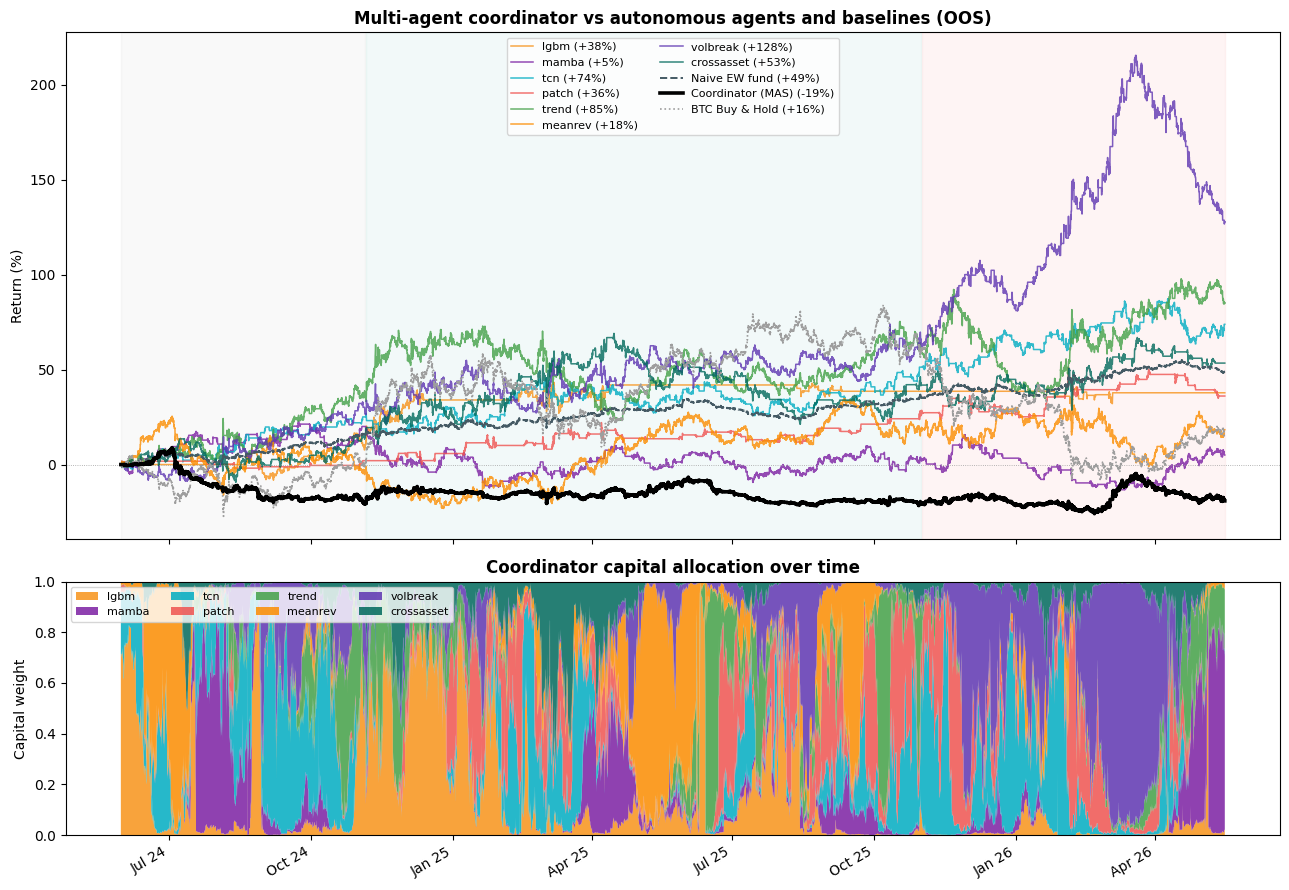

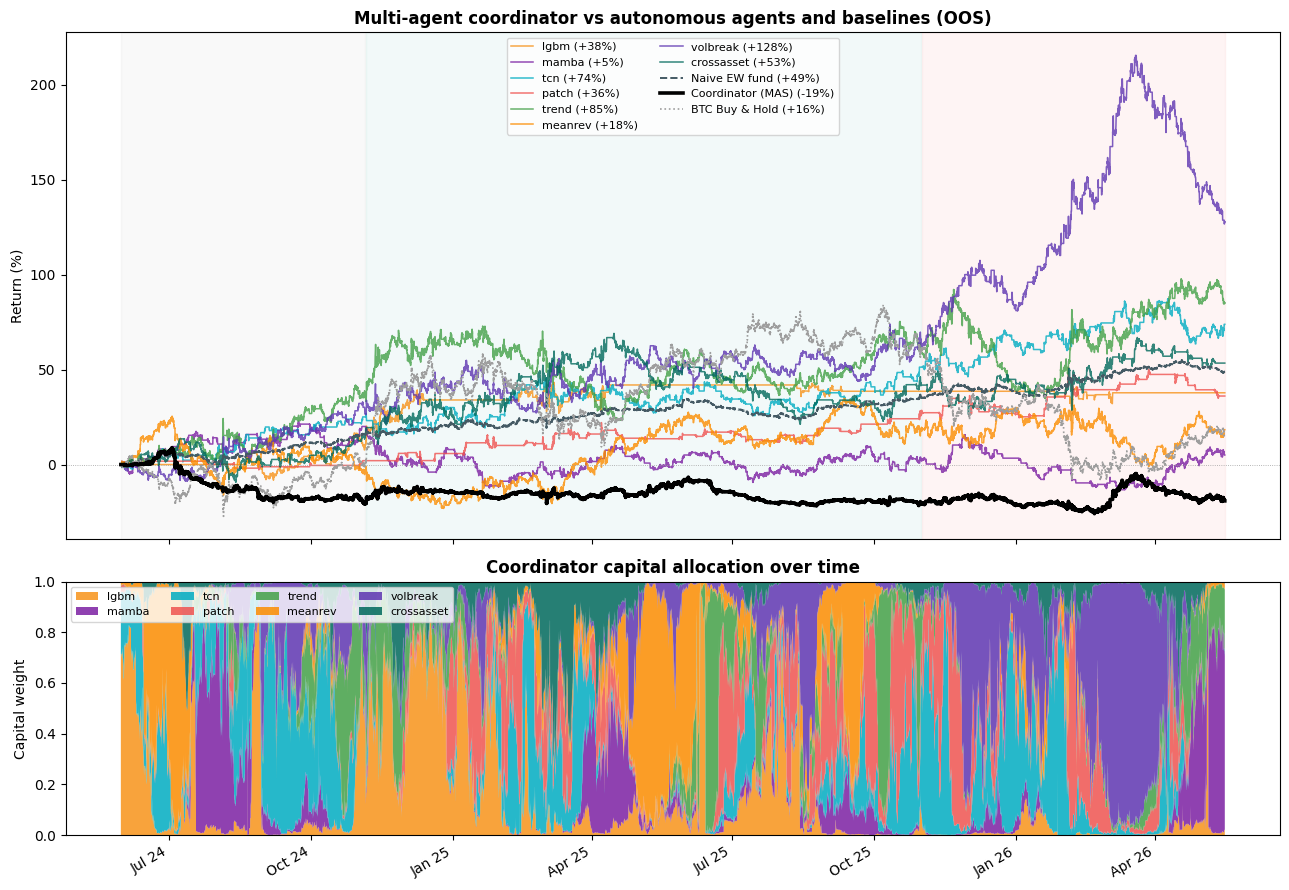

In [61]:
fig = plot_results(out, save=True)
fig

### Contribution of the rule agents (4 learned vs 7)

Re-run the coordinator on the learned-only roster and on the full roster to isolate what the
orthogonal rule agents add. Watch the **Naive EW fund** row — that is where the diversification
shows up.

In [62]:
_full = list(AGENTS)
def _summary(ags, tag):
    global AGENTS
    AGENTS = ags
    r = run_pipeline(save=False, verbose=False)
    d = {x["name"]: x for x in r["leaderboard"]}
    c, ew = d["Coordinator (MAS)"], d["Naive EW fund"]
    return {"roster": tag, "EW_ret": f'{ew["ret"]:+.1%}', "EW_sharpe": round(ew["sharpe"], 2),
            "Coord_ret": f'{c["ret"]:+.1%}', "Coord_sharpe": round(c["sharpe"], 2)}
rows = [_summary(LEARNED_AGENTS, "4 learned"),
        _summary(LEARNED_AGENTS + RULE_AGENTS, "7 (learned+rule)"),
        _summary(LEARNED_AGENTS + RULE_AGENTS + CROSS_AGENTS, "8 (+ crossasset)")]
AGENTS = _full
display(pd.DataFrame(rows))

,roster,EW_ret,EW_sharpe,Coord_ret,Coord_sharpe
0,4 learned,+34.1%,1.24,-9.7%,-0.28
1,7 (learned+rule),+48.3%,1.87,-22.2%,-0.61
2,8 (+ crossasset),+48.8%,1.96,-19.1%,-0.52


### How much is *skill*? — the random-bracket null

A headline return is dominated by two things that are **not** signal skill: the asymmetric ATR
bracket (cut losers / let winners run = positive convexity) and the trending OOS market
(directional beta). The fair benchmark is therefore *random* long/short entries through the agent's
**own** bracket, trade-count-matched. An agent has demonstrable skill only if its real return sits
in the top tail of that random distribution (`pctile ≥ 95%`).

*Random-bracket null utilities (inlined):*

In [63]:
import numpy as np
import pandas as pd



def _n_trades(pos: np.ndarray) -> int:
    return int((np.diff(np.sign(pos), prepend=0) != 0).sum())


def random_bracket_null(prob: pd.Series, df: pd.DataFrame, best_params: dict,
                        n_sims: int = 300, seed: int = 0,
                        prob_dn: pd.Series | None = None) -> dict:
    """Distribution of OOS returns from *random* long/short entries through the agent's bracket,
    trade-count-matched to the real signal. Returns the real result and its percentile vs random.
    """
    oos = (df.index >= OOS_START) & (df.index <= OOS_END)
    sub = df[oos]
    c, hi, lo = sub["close"].values, sub["high"].values, sub["low"].values
    atr = sub["atr_14_pct"].values
    n = len(sub)

    pdn = prob_dn[oos].values if prob_dn is not None else None
    eq, pos, _ = bracket_run(prob[oos].values, c, hi, lo, atr, with_fees=True,
                             prob_dn=pdn, **best_params)
    real_ret = float(eq[-1] - 1)
    n_tr = _n_trades(pos)

    lt, st = best_params["long_threshold"], best_params["short_threshold"]
    rng = np.random.default_rng(seed)
    rets = np.empty(n_sims)
    for k in range(n_sims):
        s = np.full(n, 0.5)
        # ~2x candidate entries; cooldown/min_hold thin them toward the real trade count
        locs = rng.choice(n, size=min(int(max(n_tr, 2) * 1.0), n), replace=False)
        s[locs] = rng.choice([lt + 0.05, st - 0.05], size=len(locs))
        e, _, _ = bracket_run(s, c, hi, lo, atr, with_fees=True, **best_params)
        rets[k] = e[-1] - 1
    pctile = float((rets < real_ret).mean())
    return {
        "real_ret": real_ret, "real_sharpe": float(sharpe(eq)), "real_maxdd": float(maxdd(eq)),
        "n_trades": n_tr,
        "null_mean": float(rets.mean()), "null_p50": float(np.percentile(rets, 50)),
        "null_p95": float(np.percentile(rets, 95)),
        "percentile": pctile,                 # fraction of random sims the agent beats
        "alpha_vs_null": real_ret - float(np.percentile(rets, 50)),  # return over random median
        "skill_significant": pctile >= 0.95,  # one-sided 5% test
    }


def null_table(agents: dict, df: pd.DataFrame, best_params: dict[str, dict],
               prob_dn: dict | None = None, n_sims: int = 300) -> pd.DataFrame:
    """Random-bracket-null skill table for a set of agents.

    ``agents`` maps name -> prob Series; ``best_params`` maps name -> bracket params.
    """
    rows = []
    for name, prob in agents.items():
        r = random_bracket_null(prob, df, best_params[name], n_sims=n_sims,
                                prob_dn=(prob_dn or {}).get(name))
        rows.append({"agent": name, "ret": f'{r["real_ret"]:+.1%}',
                     "null_p50": f'{r["null_p50"]:+.1%}', "null_p95": f'{r["null_p95"]:+.1%}',
                     "alpha_vs_null": f'{r["alpha_vs_null"]:+.1%}',
                     "pctile": f'{r["percentile"]:.0%}',
                     "skill_sig": "yes" if r["skill_significant"] else "no"})
    return pd.DataFrame(rows)

In [64]:
panel = out["_panel"]; a2 = repo_root() / "artifacts" / "notebooks_v2"
probs = {a: panel[a] for a in AGENTS}
pdn = {a: panel[a + "_dn"] for a in AGENTS if a in MULTICLASS}
bps = {a: json.load(open(a2 / AGENT_DIR[a] / "results.json"))["best_params"] for a in AGENTS}
skill = null_table(probs, panel, bps, prob_dn=pdn, n_sims=250)
display(skill)

,agent,ret,null_p50,null_p95,alpha_vs_null,pctile,skill_sig
0,lgbm,+37.8%,+0.8%,+57.3%,+37.0%,87%,no
1,mamba,+5.2%,-17.2%,+62.8%,+22.5%,72%,no
2,tcn,+73.8%,-8.0%,+16.7%,+81.9%,100%,yes
3,patch,+36.1%,-8.5%,+7.5%,+44.6%,100%,yes
4,trend,+85.5%,+37.1%,+159.3%,+48.4%,78%,no
5,meanrev,+16.4%,-6.4%,+82.1%,+22.8%,72%,no
6,volbreak,+132.0%,+25.7%,+141.5%,+106.3%,94%,no
7,crossasset,+53.4%,+31.5%,+126.2%,+21.9%,69%,no


**Reading it.** Only agents with `skill_sig = yes` carry predictive edge over the
bracket+beta baseline. Everything else "makes money" in this window the way a coin flip through the
same bracket would — useful only as diversification, not as alpha.

### Alternative merge methods

The notebook-07 `Coordinator` is one allocation rule among many. `coordinators.py` scores several on
the identical OOS panel — all leak-free, all at gross exposure 1.0 (so differences are pure
allocation, not leverage). The question: does *any* allocator beat naive equal weight, and is the
trailing-Sharpe momentum gate actually helping or hurting?

*Alternative allocators (inlined):*

In [65]:
import numpy as np
import pandas as pd



def _trailing_vol(agents, win=PERF_WIN, embargo=EMBARGO_H) -> pd.DataFrame:
    out = {}
    for a, ag in agents.items():
        out[a] = ag.g.rolling(win, min_periods=200).std().shift(1 + embargo)
    return pd.DataFrame(out)[list(agents)]


def _norm(W: pd.DataFrame) -> pd.DataFrame:
    # divide each row by its row-sum → align on the index (axis=0), not the columns
    return W.div(W.sum(axis=1).replace(0, np.nan), axis=0).fillna(1.0 / W.shape[1])


def equal_weight(agents, panel, perf, competence) -> pd.DataFrame:
    return pd.DataFrame(1.0 / len(agents), index=panel.index, columns=list(agents))


def inverse_vol(agents, panel, perf, competence) -> pd.DataFrame:
    vol = _trailing_vol(agents)
    inv = 1.0 / (vol + 1e-9)
    return _norm(inv.reindex(panel.index)).fillna(1.0 / len(agents))


def softmax_sharpe(agents, panel, perf, competence) -> pd.DataFrame:
    z = (perf[list(agents)] / PERF_TEMP).clip(-10, 10)
    soft = np.exp(z)
    return _norm(soft)


def mas_coordinator(agents, panel, perf, competence) -> pd.DataFrame:
    return Coordinator(competence).allocate(agents, panel, perf)


def shrink_to_ew(agents, panel, perf, competence, lam: float = 0.5) -> pd.DataFrame:
    W = mas_coordinator(agents, panel, perf, competence)
    ew = 1.0 / len(agents)
    return (1 - lam) * W + lam * ew


def inverse_vol_competence(agents, panel, perf, competence) -> pd.DataFrame:
    vol = _trailing_vol(agents).reindex(panel.index)
    inv = (1.0 / (vol + 1e-9))
    tilt = smoothed_competence(competence, panel) + COMP_FLOOR
    return _norm((inv * tilt).fillna(0.0)).fillna(1.0 / len(agents))


METHODS = {
    "Equal weight (1/N)": equal_weight,
    "Inverse-vol (risk parity)": inverse_vol,
    "Trailing-Sharpe softmax": softmax_sharpe,
    "MAS coordinator (current)": mas_coordinator,
    "Shrink-to-EW (λ=0.5)": shrink_to_ew,
    "Inv-vol × competence": inverse_vol_competence,
}


def compare(agents=None, panel=None) -> pd.DataFrame:
    """Build the panel/agents once and score every merge method on the OOS window."""
    if panel is None:
        panel = load_panel()
    if agents is None:
        agents = build_agents(panel, repo_root() / "artifacts" / "notebooks_v2")
    competence = estimate_competence(agents, panel)
    perf = trailing_sharpe(agents)
    idx = _oos(panel)
    bh = (1.0 + panel["ret"].reindex(idx)).cumprod()

    rows = []
    curves = {}
    for name, fn in METHODS.items():
        W = fn(agents, panel, perf, competence)
        eq = portfolio_equity(W, agents, idx)
        seg = eq / eq[0]
        turn = float(W.reindex(idx).diff().abs().sum(axis=1).mean())
        rows.append({"method": name, "ret": seg[-1] - 1, "sharpe": sharpe(seg),
                     "sortino": sortino(seg), "maxdd": maxdd(seg),
                     "alpha_vs_BH": seg[-1] - bh.values[-1] / bh.values[0],
                     "avg_turnover": turn})
        curves[name] = pd.Series(seg, index=idx)
    lb = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
    return lb, curves

,method,ret,sharpe,sortino,maxdd,alpha_vs_BH,avg_turnover
0,Inverse-vol (risk parity),46.1,2.09,2.34,-4.8,30.5,0.001
1,Equal weight (1/N),48.8,1.96,2.37,-8.0,33.3,0.000
2,Inv-vol × competence,39.2,1.85,2.07,-4.9,23.6,0.005
3,Shrink-to-EW (λ=0.5),10.6,0.37,0.45,-13.7,-5.0,0.027
4,Trailing-Sharpe softmax,-16.2,-0.42,-0.49,-31.4,-31.8,0.053
5,MAS coordinator (current),-19.1,-0.52,-0.61,-31.9,-34.7,0.054


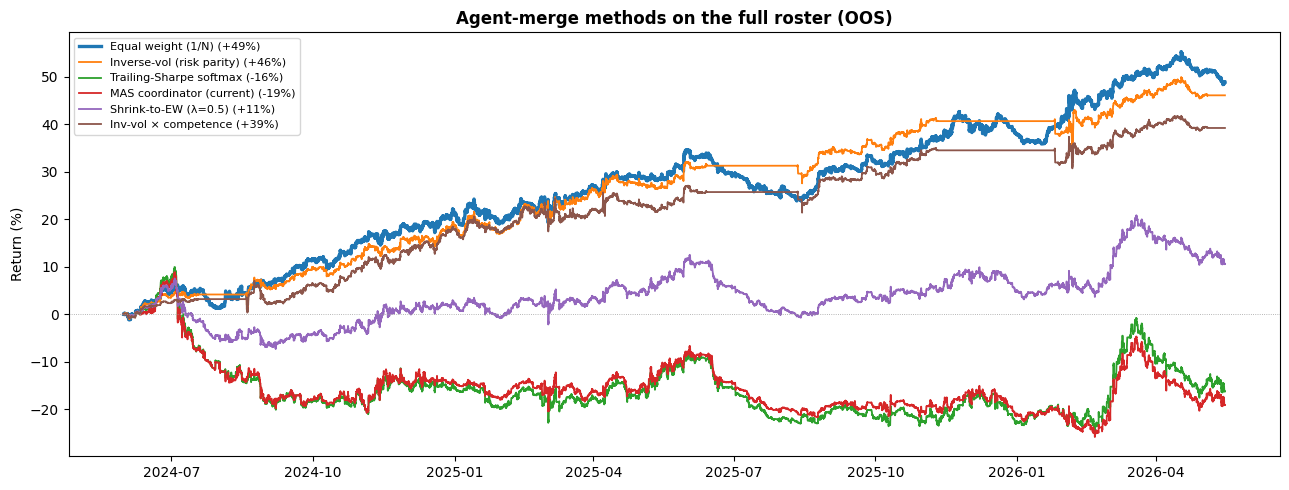

In [66]:
import matplotlib.pyplot as plt
mlb, mcurves = compare(agents=out["_agents"], panel=out["_panel"])
disp = mlb.copy()
for c in ["ret", "maxdd", "alpha_vs_BH"]:
    disp[c] = (disp[c] * 100).round(1)
disp["sharpe"] = disp["sharpe"].round(2); disp["sortino"] = disp["sortino"].round(2)
disp["avg_turnover"] = disp["avg_turnover"].round(3)
display(disp)

fig, ax = plt.subplots(figsize=(13, 5))
for name, eq in mcurves.items():
    lw = 2.4 if name.startswith("Equal") else 1.3
    ax.plot(eq.index, (eq.values - 1) * 100, lw=lw, label=f"{name} ({eq.values[-1]-1:+.0%})")
ax.axhline(0, color="#9E9E9E", lw=0.6, ls=":"); ax.set_ylabel("Return (%)"); ax.legend(fontsize=8)
ax.set_title("Agent-merge methods on the full roster (OOS)", fontweight="bold")
fig.tight_layout(); plt.show()

---
## Part C — discussion

**What works.** Wrapping each model/strategy as a risk-managed agent and allocating across them by
`online skill × regime competence` is a coherent fund-of-agents. The **rule agents are structurally
orthogonal** to the learned models (their edge is strategy logic, not the shared feature panel), so
adding them sharply improves the diversified equal-weight fund and its drawdown — the
regime-robustness the hybrid thesis is about.

**The allocation verdict (from the merge-method table above).** The current
`softmax(trailing-Sharpe) × competence` coordinator is the **worst** allocator on the panel — it and
plain trailing-Sharpe softmax are the only methods that lose money. The trailing-Sharpe momentum gate
concentrates capital into an agent just as its edge mean-reverts (high turnover, negative alpha).

**The fix is a different merge method, not more agents.** Static / risk-based weightings win:
**inverse-volatility (risk parity)** delivers the best risk-adjusted result — higher Sharpe than
equal-weight at roughly half the drawdown, with near-zero turnover. The recommended path forward is
to replace the trailing-Sharpe gate with inverse-vol risk parity (optionally tilted by *significant*
competence only), and to remember the skill table: most agents are bracket+beta, so only **tcn** and
**patch** have earned a genuine skill premium in the weighting.